In [1]:
%pip install roboflow python-dotenv
import os
import yaml
import collections
import shutil
from dotenv import load_dotenv
from roboflow import Roboflow
from collections import Counter
import glob
import matplotlib.pyplot as plt
import cv2
import numpy as np
import random
import albumentations as A
from tqdm import tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 44.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:
# Upload V2 Combined Dataset for Editing

load_dotenv()

# if google colab run:
from google.colab import userdata
V2_ROBOFLOW_API_KEY = userdata.get("V2_ROBOFLOW_API_KEY") # View API key in Secrets Doc!

rf = Roboflow(api_key=V2_ROBOFLOW_API_KEY)
project = rf.workspace("caretech-v2").project("v2-caretech-combined-dataset")
dataset = project.version(1).download("yolov8") # CHANGE THIS IF YOU WANT A DIFFERENT MODEL


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to V2-CareTech-Combined-Dataset-1 in yolov8:: 100%|██████████| 58568/58568 [00:13<00:00, 4359.87it/s]


In [9]:
# Sanity Check Dataset

def print_image_counts(DATASET_PATH):
  TRAIN_IMAGES = os.path.join(DATASET_PATH, "train/images")
  TRAIN_LABELS = os.path.join(DATASET_PATH, "train/labels")

  VAL_IMAGES = os.path.join(DATASET_PATH, "valid/images")
  VAL_LABELS = os.path.join(DATASET_PATH, "valid/labels")

  TEST_IMAGES = os.path.join(DATASET_PATH, "test/images")
  TEST_LABELS = os.path.join(DATASET_PATH, "test/labels")

  print("Train images:", len(os.listdir(TRAIN_IMAGES)))
  print("Train labels:", len(os.listdir(TRAIN_LABELS)))
  print("Val images:", len(os.listdir(VAL_IMAGES)))
  print("Val labels:", len(os.listdir(VAL_LABELS)))
  print("Test images:", len(os.listdir(TEST_IMAGES)))
  print("Test labels:", len(os.listdir(TEST_LABELS)))

DATASET_PATH = dataset.location
print_image_counts(DATASET_PATH)

Train images: 20508
Train labels: 20508
Val images: 5821
Val labels: 5821
Test images: 2949
Test labels: 2949


In [4]:
# sanity check yusuf dataset

def class_count(label_dir):
    counts = Counter()
    for lf in glob.glob(os.path.join(label_dir, "*.txt")):
        with open(lf) as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                try:
                    cid = int(parts[0])
                except ValueError:
                    continue
                counts[cid] += 1
    return counts

TRAIN_LABELS = os.path.join(DATASET_PATH, "train/labels")
train_counts = class_count(TRAIN_LABELS)
print("Yusuf train class IDs:", sorted(train_counts.keys()))
print("Number of classes", len(train_counts.keys()))
print("Class per ID", train_counts)


Yusuf train class IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215]
Number

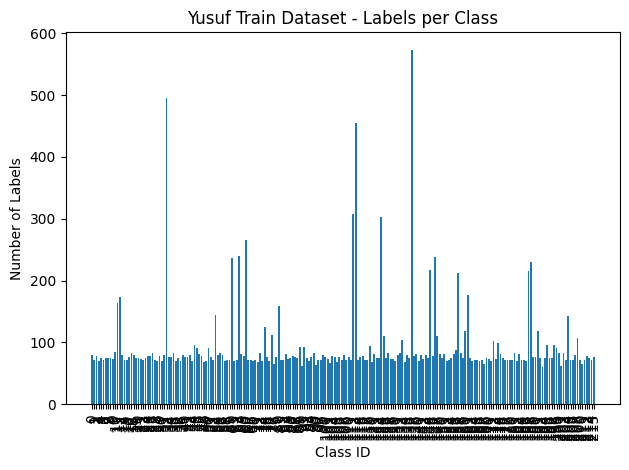

In [5]:

def plot_class_counts(train_counts):
  class_ids = sorted(train_counts.keys())
  counts = [train_counts[cid] for cid in class_ids]

  plt.figure()
  plt.bar(class_ids, counts)

  plt.xticks(class_ids, rotation=90)
  plt.xlabel("Class ID")
  plt.ylabel("Number of Labels")
  plt.title("Yusuf Train Dataset - Labels per Class")

  plt.tight_layout()
  plt.show()

  return counts, class_ids

counts, class_ids = plot_class_counts(train_counts)

In [ ]:
print(train_counts[0])

79


In [ ]:
total = sum(counts)
for cid, c in zip(class_ids, counts):
    print(f"Class {cid}: {c} ({c/total:.2%})")

Class 0: 79 (0.39%)
Class 1: 72 (0.36%)
Class 2: 78 (0.39%)
Class 3: 69 (0.34%)
Class 4: 75 (0.37%)
Class 5: 72 (0.36%)
Class 6: 74 (0.37%)
Class 7: 74 (0.37%)
Class 8: 74 (0.37%)
Class 9: 73 (0.36%)
Class 10: 85 (0.42%)
Class 11: 164 (0.81%)
Class 12: 174 (0.86%)
Class 13: 80 (0.40%)
Class 14: 72 (0.36%)
Class 15: 71 (0.35%)
Class 16: 77 (0.38%)
Class 17: 82 (0.41%)
Class 18: 79 (0.39%)
Class 19: 75 (0.37%)
Class 20: 74 (0.37%)
Class 21: 73 (0.36%)
Class 22: 72 (0.36%)
Class 23: 74 (0.37%)
Class 24: 78 (0.39%)
Class 25: 78 (0.39%)
Class 26: 83 (0.41%)
Class 27: 71 (0.35%)
Class 28: 70 (0.35%)
Class 29: 78 (0.39%)
Class 30: 70 (0.35%)
Class 31: 80 (0.40%)
Class 32: 496 (2.46%)
Class 33: 76 (0.38%)
Class 34: 76 (0.38%)
Class 35: 83 (0.41%)
Class 36: 70 (0.35%)
Class 37: 75 (0.37%)
Class 38: 69 (0.34%)
Class 39: 80 (0.40%)
Class 40: 76 (0.38%)
Class 41: 77 (0.38%)
Class 42: 79 (0.39%)
Class 43: 69 (0.34%)
Class 44: 95 (0.47%)
Class 45: 91 (0.45%)
Class 46: 81 (0.40%)
Class 47: 78 (0.39%)

In [ ]:
os.environ["LAHARI_AUDREY_ROBOFLOW_API_KEY"] = userdata.get("LAHARI_AUDREY_ROBOFLOW_API_KEY")
api_key = os.getenv("LAHARI_AUDREY_ROBOFLOW_API_KEY")

rf_al = Roboflow(api_key=api_key)

In [ ]:
# ITERATION 1: training the baseline model with the original dataset to get the baseline metrics
# Chosen model: yolov26, 70 epochs, img_size=640x640

WORKSPACE_SLUG = "lahari-audrey-workspace"
workspace = rf_al.workspace(WORKSPACE_SLUG)
workspace.upload_dataset(
   "/content/V2-CareTech-Combined-Dataset-1", # dataset path
   "baseline-dataset-fntka", # project id (slug)
   num_workers=10,
   project_license="MIT",
   project_type="object-detection",
   batch_name='baseline-dataset',
   num_retries=0,
   is_prediction=False,
)

Model: yolov26 fast, epochs=70, img_size=640x640

Dataset: Original combined dataset

Metrics:
*   mAP@50: 72.3%
*   Precision: 71.0%
*   Recall: 65.3%

In [3]:
!rm -rf "/content/preprocessing-V2-CareTech-Combined-Dataset-1"

In [4]:
# make a copy of the dataset for preprocessing
!cp -R "/content/V2-CareTech-Combined-Dataset-1" "/content/preprocessing-V2-CareTech-Combined-Dataset-1"

In [5]:
''' Merge classes that are visually similar, variants of the same dish, and/or have low accuracy (and where nutritional difference is negligible)
- Merge croquette and kushikatu into breaded-fried-food
- Merge tanmen, tension-noodle, and ramen-noodle into ramen-style-noodle-soup
- Merge yellow-curry and egg-noodle-in-chicken-yellow-curry into yellow-curry-dish
- Merge japanese-tofu-and-vegetable-chowder and clear-soup into Japanese-soup
'''

DATASET_PATH = "/content/preprocessing-V2-CareTech-Combined-Dataset-1"
DATA_YAML = "/content/preprocessing-V2-CareTech-Combined-Dataset-1/data.yaml"

# Load class names
with open(DATA_YAML, "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]

# Merge mapping
merge_map = {
    "croquette": "breaded-fried-food",
    "kushikatu": "breaded-fried-food",

    "tanmen": "ramen-style-noodle-soup",
    "tensin-noodle": "ramen-style-noodle-soup",
    "ramen-noodle": "ramen-style-noodle-soup",

    "yellow-curry": "yellow-curry-dish",
    "egg-noodle-in-chicken-yellow-curry": "yellow-curry-dish",

    "japanese-tofu-and-vegetable-chowder": "japanese-soup",
    "clear-soup": "japanese-soup",
}

# Build new class list
new_class_names = []
for name in class_names:
    if name in merge_map:
        new_name = merge_map[name]
    else:
        new_name = name

    if new_name not in new_class_names:
        new_class_names.append(new_name)

# Mapping old_id → new_id
old_to_new_id = {}

for old_id, name in enumerate(class_names):
    if name in merge_map:
        new_name = merge_map[name]
    else:
        new_name = name

    new_id = new_class_names.index(new_name)
    old_to_new_id[old_id] = new_id

print("Old → New class ID mapping:")
print(old_to_new_id)

# Function to update label files
def update_labels(label_dir):
    for file in os.listdir(label_dir):
        if not file.endswith(".txt"):
            continue
        path = os.path.join(label_dir, file)
        new_lines = []
        with open(path, "r") as f:
            for line in f:
                array = line.strip().split()
                old_class_id = int(array[0])
                new_class_id = old_to_new_id[old_class_id]
                array[0] = str(new_class_id)
                new_lines.append(" ".join(array))
        with open(path, "w") as f:
            f.write("\n".join(new_lines))

# Update train/valid/test labels
for split in ["train", "valid", "test"]:
    label_dir = os.path.join(DATASET_PATH, split, "labels")
    if os.path.exists(label_dir):
        print(f"Updating labels in {label_dir}")
        update_labels(label_dir)

# Save new class names
data["names"] = new_class_names
data["nc"] = len(new_class_names)

with open("/content/preprocessing-V2-CareTech-Combined-Dataset-1/data.yaml", "w") as f:
    yaml.dump(data, f)

print("New classes:", new_class_names)
print("Updated data.yaml with merged classes.")

Old → New class ID mapping:
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 25, 26: 26, 27: 27, 28: 28, 29: 29, 30: 30, 31: 31, 32: 32, 33: 33, 34: 34, 35: 35, 36: 36, 37: 37, 38: 38, 39: 39, 40: 40, 41: 41, 42: 42, 43: 43, 44: 44, 45: 45, 46: 46, 47: 47, 48: 48, 49: 49, 50: 50, 51: 51, 52: 52, 53: 53, 54: 54, 55: 55, 56: 56, 57: 57, 58: 58, 59: 59, 60: 60, 61: 61, 62: 62, 63: 63, 64: 64, 65: 65, 66: 66, 67: 67, 68: 68, 69: 69, 70: 70, 71: 71, 72: 72, 73: 73, 74: 74, 75: 75, 76: 76, 77: 77, 78: 78, 79: 79, 80: 80, 81: 81, 82: 82, 83: 83, 84: 84, 85: 85, 86: 86, 87: 87, 88: 88, 89: 89, 90: 32, 91: 90, 92: 91, 93: 92, 94: 93, 95: 94, 96: 95, 97: 40, 98: 96, 99: 97, 100: 98, 101: 99, 102: 100, 103: 101, 104: 102, 105: 103, 106: 104, 107: 105, 108: 106, 109: 107, 110: 108, 111: 109, 112: 110, 113: 111, 114: 112, 115: 113, 116: 114, 117: 115, 118: 116, 119

Yusuf train class IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210]
Number of classes 211
Class per

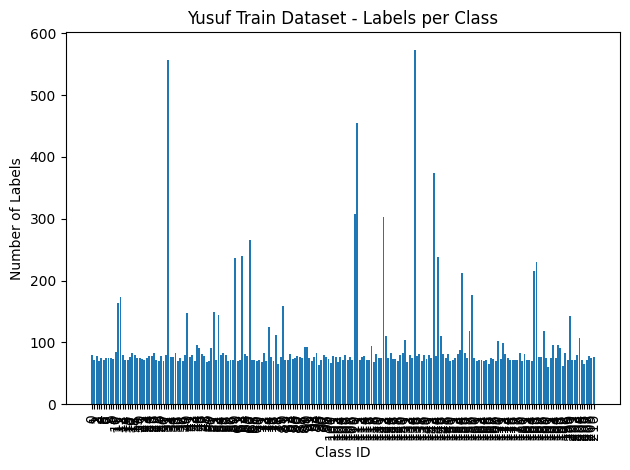

Class 0: 79 (0.39%)
Class 1: 72 (0.36%)
Class 2: 78 (0.39%)
Class 3: 69 (0.34%)
Class 4: 75 (0.37%)
Class 5: 72 (0.36%)
Class 6: 74 (0.37%)
Class 7: 74 (0.37%)
Class 8: 74 (0.37%)
Class 9: 73 (0.36%)
Class 10: 85 (0.42%)
Class 11: 164 (0.81%)
Class 12: 174 (0.86%)
Class 13: 80 (0.40%)
Class 14: 72 (0.36%)
Class 15: 71 (0.35%)
Class 16: 77 (0.38%)
Class 17: 82 (0.41%)
Class 18: 79 (0.39%)
Class 19: 75 (0.37%)
Class 20: 74 (0.37%)
Class 21: 73 (0.36%)
Class 22: 72 (0.36%)
Class 23: 74 (0.37%)
Class 24: 78 (0.39%)
Class 25: 78 (0.39%)
Class 26: 83 (0.41%)
Class 27: 71 (0.35%)
Class 28: 70 (0.35%)
Class 29: 78 (0.39%)
Class 30: 70 (0.35%)
Class 31: 80 (0.40%)
Class 32: 557 (2.77%)
Class 33: 76 (0.38%)
Class 34: 76 (0.38%)
Class 35: 83 (0.41%)
Class 36: 70 (0.35%)
Class 37: 75 (0.37%)
Class 38: 69 (0.34%)
Class 39: 80 (0.40%)
Class 40: 147 (0.73%)
Class 41: 77 (0.38%)
Class 42: 79 (0.39%)
Class 43: 69 (0.34%)
Class 44: 95 (0.47%)
Class 45: 91 (0.45%)
Class 46: 81 (0.40%)
Class 47: 78 (0.39%

In [ ]:
TRAIN_LABELS = os.path.join(DATASET_PATH, "train/labels")
train_counts = class_count(TRAIN_LABELS)
print("Yusuf train class IDs:", sorted(train_counts.keys()))
print("Number of classes", len(train_counts.keys()))
print("Class per ID", train_counts)

counts, class_ids = plot_class_counts(train_counts)

total = sum(counts)
for cid, c in zip(class_ids, counts):
    print(f"Class {cid}: {c} ({c/total:.2%})")

In [6]:
# use laplacian variance to remove blurry outliers

# first compute the blurriness scores for all images and see what the score range is

def laplacian_variance(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

DATASET_PATH = "/content/preprocessing-V2-CareTech-Combined-Dataset-1"
scores = []

for split in ["train", "valid", "test"]:
    image_dir = os.path.join(DATASET_PATH, split, "images")
    for fname in os.listdir(image_dir):
        if fname.endswith((".jpg", ".jpeg", ".png")):
            path = os.path.join(image_dir, fname)
            score = laplacian_variance(path)
            scores.append((fname,score))

values = [score for _, score in scores]

print("Min:", min(values))
print("Max:", max(values))
print("Mean:", np.mean(values))
print("Median:", np.median(values))
print("5th percentile:", np.percentile(values, 5))
print("1st percentile:", np.percentile(values, 1))

Min: 3.7312864458395367
Max: 24946.41137186791
Mean: 1002.1166830104813
Median: 554.9648636338393
5th percentile: 79.56309619735885
1st percentile: 30.508912838952533


In [ ]:
# inspecting the top 250 blurry images
scores.sort(key=lambda x: x[1])

for fname, score in scores[:250]:
    print(fname, score)

yusuf_4163d30eba358af1_jpg.rf.8bd6e86bf7947fe83ee27461ee43ef98.jpg 3.7312864458395367
yusuf_500d6cdc7e8fb3e1_jpg.rf.0b95649705b036c80d03056296048467.jpg 4.012683626249782
yusuf_14802_jpg.rf.9236c8ac7d459e90cf4a192d3ee61d02.jpg 4.167499348280167
chicken_nugget_081267_jpg.rf.6bf244ac526ba187caa19aa54e008207.jpg 4.236597283157333
hamburger_014982_jpg.rf.4aa4a33f49521d326f868f411bbf7049.jpg 4.272799411349826
omelet_67_010928_jpg.rf.0a1f450ae13a1410d3692c2b4f400262.jpg 4.483388149300198
yusuf_deef6ea77bdb97e9_jpg.rf.0d9728def07c1eb898ff66bab25b7a69.jpg 4.655860900775425
egg_roll_010909_jpg.rf.8c9505c6d25a5dc5223d0557d093a026.jpg 6.466936581006463
yusuf_10935_jpg.rf.febc0e8c93bc5035c49a2ce674ac45be.jpg 6.505335648014189
almond_jelly_068124_jpg.rf.b2f489675338b35f90ca093b907c04fe.jpg 6.676227521136001
steamed_egg_hotchpotch_005378_jpg.rf.6b4e6d33fcee895b136c0c0a9d090923.jpg 6.6896054362456585
scrambled_egg_103519_jpg.rf.d657c820077b3be358485571172c5020.jpg 6.747087526655998
yusuf_52c33abf081b

In [7]:
# chosen blurry score threshold = 35 = ~top 1% of blurry images
# remove around 250-350 blurry outliers

threshold = 35
print("Chosen blur threshold:", threshold)

moved = 0
DATASET_PATH = "/content/preprocessing-V2-CareTech-Combined-Dataset-1"
BLURRY_PATH = "/content/dataset_blurry"

for split in ["train", "valid", "test"]:
    files = []
    image_dir = os.path.join(DATASET_PATH, split, "images")
    label_dir = os.path.join(DATASET_PATH, split, "labels")
    blurry_img_dir = os.path.join(BLURRY_PATH, split, "images")
    blurry_lbl_dir = os.path.join(BLURRY_PATH, split, "labels")
    os.makedirs(blurry_img_dir, exist_ok=True)
    os.makedirs(blurry_lbl_dir, exist_ok=True)

    for fname in os.listdir(image_dir):
      if fname.lower().endswith((".jpg", ".jpeg", ".png")):
          path = os.path.join(image_dir, fname)
          score = laplacian_variance(path)
          if score is not None:
              files.append((fname, score))

    for fname, score in files:
        if score < threshold:
            src_img = os.path.join(image_dir, fname)
            dst_img = os.path.join(blurry_img_dir, fname)
            shutil.move(src_img, dst_img)

            label_name = os.path.splitext(fname)[0] + ".txt"
            src_lbl = os.path.join(label_dir, label_name)
            dst_lbl = os.path.join(blurry_lbl_dir, label_name)
            if os.path.exists(src_lbl):
                shutil.move(src_lbl, dst_lbl)
            moved += 1

print(f"Removed {moved} blurry images")

Chosen blur threshold: 35
Removed 379 blurry images


In [10]:
DATASET_PATH = "/content/preprocessing-V2-CareTech-Combined-Dataset-1"
print_image_counts(DATASET_PATH)

Train images: 20238
Train labels: 20238
Val images: 5756
Val labels: 5756
Test images: 2905
Test labels: 2905


In [ ]:
# ITERATION 2: training the model after preprocessing/cleaning the data (merging classes into superclasses, and removing blurry outliers)
# Chosen model: yolov26, 70 epochs, img_size=640x640

WORKSPACE_SLUG = "lahari-audrey-workspace"
workspace = rf_al.workspace(WORKSPACE_SLUG)
workspace.upload_dataset(
   "/content/preprocessing-V2-CareTech-Combined-Dataset-1", # dataset path
   "preprocessed-dataset", # project id (slug)
   num_workers=10,
   project_license="MIT",
   project_type="object-detection",
   batch_name='preprocessed-dataset',
   num_retries=0,
   is_prediction=False,
)

Model: yolov26 fast, epochs=70, img_size=640x640

Dataset: Preprocessed (cleaned) dataset

Metrics:
*   mAP@50: 71.8%
*   Precision: 68.7%
*   Recall: 66%

Notes:
* Decreased precision but increased recall

In [19]:
!rm -rf "/content/balanced-V2-CareTech-Combined-Dataset-1"

In [11]:
# make a copy of the dataset for class balancing/ablating
!cp -R "/content/preprocessing-V2-CareTech-Combined-Dataset-1" "/content/balanced-V2-CareTech-Combined-Dataset-1"

Train label files: 20102

Top  20  Classes by image count:
pork-cutlet: 569 images
japanese-soup: 485 images
mixed-rice: 408 images
ramen-style-noodle-soup: 336 images
omelet: 300 images
miso-soup: 299 images
fried-rice: 261 images
fried-noodle: 238 images
fried-chicken: 234 images
stir-fried-chicken: 230 images
rice: 218 images
stir-fried-beef: 216 images
salmon: 211 images
beef-noodle-soup: 173 images
sashimi: 172 images
beef-curry: 160 images
yellow-curry-dish: 148 images
breaded-fried-food: 146 images
hamburger: 136 images
toast: 134 images


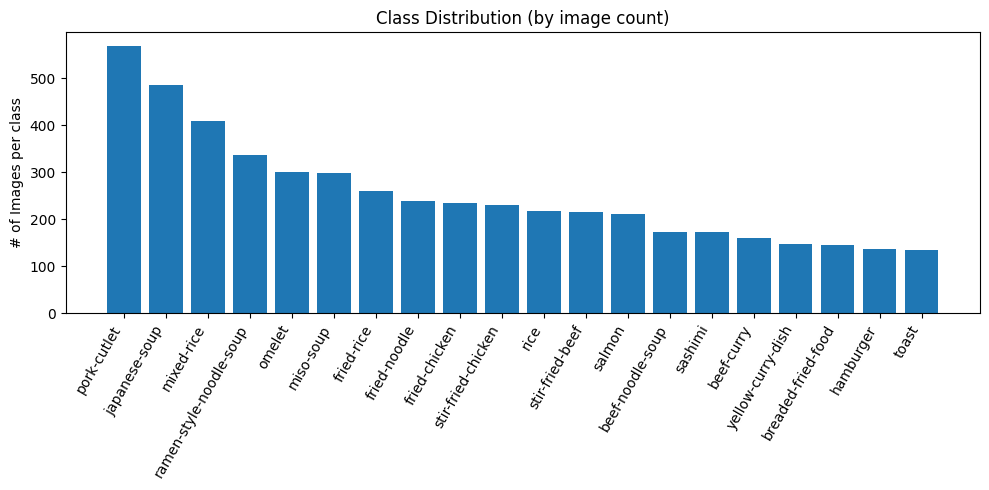

In [22]:
# count how many images per class, show top 20

from collections import defaultdict
from pathlib import Path

def count_images_per_class(ds,labels_dir,id_to_name, top_n, graph):
  image_count = {} # for each class, how many images contain that class
  label_files_by_class = defaultdict(list) # for each class, which images contain that class

  label_files = sorted(labels_dir.glob("*.txt"))
  print("Train label files:", len(label_files))

  for lf in label_files:
      if lf.stat().st_size == 0: # if image has no annotations, skip
          continue
      classes = set()
      with open(lf, "r") as f:
          for line in f:
              arr = line.strip().split()
              if not line:
                  continue
              cls = int(float(arr[0]))
              classes.add(cls)
      for cls in classes:
          image_count[cls] = image_count.get(cls, 0) + 1
          label_files_by_class[cls].append(lf)

  TOP_N = top_n
  print("\nTop ", TOP_N, " Classes by image count:")
  top_classes = sorted(image_count.items(), key=lambda x: x[1], reverse=True)[:TOP_N]
  for cls, count in top_classes:
      print(f"{id_to_name[cls]}: {count} images")

  # graph histogram of number of images per class (for top N classes)
  if graph:
    names  = [id_to_name[cls] for cls, count in top_classes]
    counts = [count for cls, count in top_classes]

    plt.figure(figsize=(10, 5))
    plt.bar(names, counts)
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("# of Images per class")
    plt.title("Class Distribution (by image count)")
    plt.tight_layout()
    plt.show()

  return image_count, label_files_by_class

ds = Path("/content/balanced-V2-CareTech-Combined-Dataset-1")
labels_dir = ds / "train" / "labels"
with open(ds/"data.yaml", "r") as f:
      data = yaml.safe_load(f)
id_to_name = {i: name for i, name in enumerate(data["names"])} # get class names
image_count, label_files_by_class = count_images_per_class(ds,labels_dir,id_to_name, 20, True)

Found 1365 candidate images
Removing 136 images (~10%)
Train label files: 20102

Top  20  Classes by image count:
pork-cutlet: 569 images
japanese-soup: 485 images
mixed-rice: 408 images
ramen-style-noodle-soup: 336 images
omelet: 300 images
miso-soup: 299 images
fried-rice: 261 images
fried-noodle: 238 images
fried-chicken: 234 images
stir-fried-chicken: 230 images
rice: 218 images
stir-fried-beef: 216 images
salmon: 211 images
beef-noodle-soup: 173 images
sashimi: 172 images
beef-curry: 160 images
yellow-curry-dish: 148 images
breaded-fried-food: 146 images
hamburger: 136 images
toast: 134 images


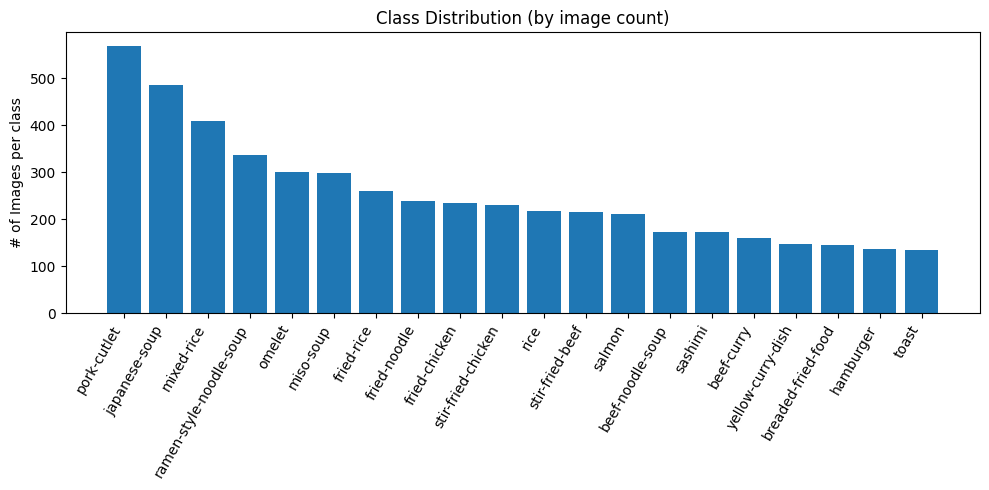

In [13]:
# Pork cutlet is the top class, but it is frequently confused by the model, so I will not remove images from it.
# Instead, I will remove 10% of images that contain the next top 3 classes: japanese-soup, mixed-rice, and ramen-style-noodle-soup

ds_abl = Path("/content/balanced-V2-CareTech-Combined-Dataset-1")
labels_dir = ds_abl / "train" / "labels"
label_files = sorted(labels_dir.glob("*.txt"))
image_dir = ds_abl / "train" / "images"
with open(ds_abl/"data.yaml", "r") as f:
    data = yaml.safe_load(f)
id_to_name = {i: name for i, name in enumerate(data["names"])} # get class names

target_classes = ['japanese-soup', 'mixed-rice', 'ramen-style-noodle-soup']
ablation_ratio = 0.10
random.seed(42)

# generate list of candidate images to remove 10% from
candidate_images = []
for lf in label_files:
    if lf.stat().st_size == 0: # if image has no annotations, skip
        continue
    with open(lf, "r") as f:
        for line in f:
          # check if this image contains any target class
          arr = line.strip().split()
          if not line:
              continue
          class_id = int(arr[0])
          if id_to_name[class_id] in target_classes:
              image_file = lf.parent / lf.name.replace(".txt", ".jpg")
              candidate_images.append(image_file)
              break

# randomly selecte 10% to delete
num_to_remove = int(len(candidate_images) * ablation_ratio)
images_to_remove = random.sample(candidate_images, num_to_remove)
print(f"Found {len(candidate_images)} candidate images")
print(f"Removing {num_to_remove} images (~10%)")

# delete them
for img in images_to_remove:
    img_path = os.path.join(image_dir, img)
    label_path = os.path.join(labels_dir, img.parent/img.name.replace(".jpg", ".txt"))
    if os.path.exists(img_path):
        os.remove(img_path)
    if os.path.exists(label_path): # remove both the image and the label
        os.remove(label_path)

# re-check image count per class
image_count, label_files_by_class = count_images_per_class(ds_abl,labels_dir,id_to_name,20,True)

In [32]:
os.environ["AUDREY_API_KEY"] = userdata.get("AUDREY_API_KEY")
api_key = os.getenv("AUDREY_API_KEY")
rf_al = Roboflow(api_key=api_key)

In [ ]:
# ITERATION 3: training the model after balancing the data (10% controlled dataset ablation)
# Chosen model: yolov26, 70 epochs, img_size=640x640

WORKSPACE_SLUG = "audreys-workspace-po1fb"
workspace = rf_al.workspace(WORKSPACE_SLUG)
workspace.upload_dataset(
   "/content/balanced-V2-CareTech-Combined-Dataset-1", # dataset path
   "balanced-sumdz", # project id (slug)
   num_workers=10,
   project_license="MIT",
   project_type="object-detection",
   batch_name='balanced-sumdz',
   num_retries=0,
   is_prediction=False,
)

Model: yolov26 fast, epochs=70, img_size=640x640

Dataset: Balanced (ablated) dataset

Metrics:
*   mAP@50: 71.7%
*   Precision: 71.2%
*   Recall: 64.0%

Notes:
* Improved precision but decreased recall
* chicken cutlet is often confused with pork cutlet
* apple, pork foods, chicken cutlet, etc. need more data
* remove meat-loaf class

In [24]:
!rm -rf "/content/augmented-V2-CareTech-Combined-Dataset-1"

In [25]:
# make a copy of the dataset for augmenting
!cp -R "/content/balanced-V2-CareTech-Combined-Dataset-1" "/content/augmented-V2-CareTech-Combined-Dataset-1"

In [26]:
# upscaling & augmenting minority classes
# "minority classes" = classes whose mAP50 < 50%

DATASET_ROOT = "/content/augmented-V2-CareTech-Combined-Dataset-1"
TRAIN_IMAGES_DIR = os.path.join(DATASET_ROOT, "train", "images")
TRAIN_LABELS_DIR = os.path.join(DATASET_ROOT, "train", "labels")

MINORITY_CLASSES = ["apple", "chicken-cutlet", "crape", "fried-fish", "grilled-eggplant", "jambalaya",
                    "noodles-with-fish-curry", "orange", "pork-belly", "pork-with-lemon", "rice-crispy-pork",
                    "sausage", "sauteed-vegetables", "stewed-pork-leg", "tempura", "tortilla", "vegetable-tempura"]

MINORITY_CLASS_IDS = [data["names"].index(cls) for cls in MINORITY_CLASSES]

# original + 2 augmented copies = ~3x total for selected images
AUGS_PER_IMAGE = 2
# Bright image threshold (higher = fewer images treated as too bright)
BRIGHTNESS_THRESHOLD = 200
# Random seed
random.seed(42)
np.random.seed(42)

IMG_EXTS = [".jpg", ".jpeg", ".png"]

# helpers
def get_label_path_from_image(img_path):
    base = os.path.splitext(os.path.basename(img_path))[0]
    return os.path.join(TRAIN_LABELS_DIR, base + ".txt")

def read_yolo_label(label_path):
    """
    Reads YOLO label file.
    Returns:
        class_ids: list[int]
        bboxes: list[[x_center, y_center, w, h]] normalized to [0,1]
    """
    class_ids = []
    bboxes = []

    if not os.path.exists(label_path):
        return class_ids, bboxes

    with open(label_path, "r") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    for line in lines:
        parts = line.split()
        if len(parts) != 5:
            continue

        cls_id = int(float(parts[0]))
        x, y, w, h = map(float, parts[1:])
        class_ids.append(cls_id)
        bboxes.append([x, y, w, h])

    return class_ids, bboxes

def write_yolo_label(label_path, class_ids, bboxes):
    with open(label_path, "w") as f:
        for cls_id, bbox in zip(class_ids, bboxes):
            x, y, w, h = bbox
            f.write(f"{cls_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

def image_contains_minority_class(label_path, minority_ids):
    class_ids, bboxes = read_yolo_label(label_path)
    return any(cls_id in minority_ids for cls_id in class_ids)

def collect_target_images():
    image_paths = []
    for ext in IMG_EXTS:
        image_paths.extend(glob.glob(os.path.join(TRAIN_IMAGES_DIR, f"*{ext}")))

    target_images = []
    for img_path in image_paths:
        label_path = get_label_path_from_image(img_path)
        if image_contains_minority_class(label_path, MINORITY_CLASS_IDS):
            target_images.append(img_path)

    return sorted(target_images)

def is_too_bright(image_rgb, threshold=200):
    """
    Detects whether an image is overly bright using mean grayscale intensity.
    """
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    return gray.mean() > threshold

def apply_clahe_to_bright(image_rgb):
    """
    Apply CLAHE to the lightness channel only.
    Useful for overly bright / washed-out images.
    """
    lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)

    merged = cv2.merge((l_clahe, a, b))
    result = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
    return result

def build_augmentation_pipeline():
    """
    Albumentations pipeline for minority-class images.
    """
    return A.Compose(
        [
            A.HorizontalFlip(p=0.50),

            A.Affine(
                scale=(1.0, 1.0),
                translate_percent=(0.0, 0.0),
                rotate=(-7, 7),
                shear=(-5, 5),
                p=0.25
            ),

            A.RandomBrightnessContrast(
                brightness_limit=(-0.25, 0.15),  # allow darkening bright images
                contrast_limit=0.15,
                p=0.30
            ),

            A.HueSaturationValue(
                hue_shift_limit=5,
                sat_shift_limit=10,
                val_shift_limit=0,
                p=0.15
            ),

            A.RandomGamma(
                gamma_limit=(80, 120),
                p=0.20
            ),

            A.Blur(
                blur_limit=(3, 5),
                p=0.10
            ),
        ],
        bbox_params=A.BboxParams(
            format="yolo",
            label_fields=["class_labels"],
            min_visibility=0.2
        )
    )

def save_augmented_sample(original_img_path, aug_index, transformed_image, transformed_bboxes, transformed_class_ids):
    base_name = os.path.splitext(os.path.basename(original_img_path))[0]
    ext = os.path.splitext(original_img_path)[1]

    new_img_name = f"{base_name}_aug{aug_index}{ext}"
    new_lbl_name = f"{base_name}_aug{aug_index}.txt"

    new_img_path = os.path.join(TRAIN_IMAGES_DIR, new_img_name)
    new_lbl_path = os.path.join(TRAIN_LABELS_DIR, new_lbl_name)

    cv2.imwrite(new_img_path, transformed_image)
    write_yolo_label(new_lbl_path, transformed_class_ids, transformed_bboxes)

# main
def augment_minority_class_images():
    target_images = collect_target_images()
    print(f"Found {len(target_images)} training images containing minority classes: {MINORITY_CLASS_IDS}")
    transform = build_augmentation_pipeline()
    saved_count = 0
    bright_count = 0
    skipped_empty_boxes = 0

    for img_path in tqdm(target_images):
        label_path = get_label_path_from_image(img_path)

        image_bgr = cv2.imread(img_path)
        if image_bgr is None:
            print(f"Warning: could not read image {img_path}")
            continue

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        class_ids, bboxes = read_yolo_label(label_path)
        if len(bboxes) == 0:
            continue

        for aug_num in range(1, AUGS_PER_IMAGE + 1):
            working_image = image_rgb.copy()

            # Apply CLAHE only if image is too bright
            if is_too_bright(working_image, threshold=BRIGHTNESS_THRESHOLD):
                working_image = apply_clahe_to_bright(working_image)
                bright_count += 1

            try:
                transformed = transform(
                    image=working_image,
                    bboxes=bboxes,
                    class_labels=class_ids
                )

                aug_image = transformed["image"]
                aug_bboxes = transformed["bboxes"]
                aug_class_ids = transformed["class_labels"]

                # Skip if all boxes got dropped
                if len(aug_bboxes) == 0:
                    skipped_empty_boxes += 1
                    continue

                aug_image_bgr = cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR)

                save_augmented_sample(
                    original_img_path=img_path,
                    aug_index=aug_num,
                    transformed_image=aug_image_bgr,
                    transformed_bboxes=aug_bboxes,
                    transformed_class_ids=aug_class_ids
                )
                saved_count += 1

            except Exception as e:
                print(f"Error augmenting {img_path}: {e}")

    print("\nDone.")
    print(f"Saved augmented image-label pairs: {saved_count}")
    print(f"Augmentations where CLAHE was applied to bright images: {bright_count}")
    print(f"Skipped augmentations due to all boxes being dropped: {skipped_empty_boxes}")

augment_minority_class_images()

Found 1140 training images containing minority classes: [2, 25, 36, 61, 76, 88, 118, 123, 134, 138, 147, 160, 162, 183, 194, 201, 205]


100%|██████████| 1140/1140 [00:18<00:00, 60.07it/s]


Done.
Saved augmented image-label pairs: 2280
Augmentations where CLAHE was applied to bright images: 20
Skipped augmentations due to all boxes being dropped: 0


In [27]:
DATASET_PATH = "/content/augmented-V2-CareTech-Combined-Dataset-1"
print_image_counts(DATASET_PATH)

Train images: 22518
Train labels: 22382
Val images: 5756
Val labels: 5756
Test images: 2905
Test labels: 2905


Train label files: 22382

Top  210  Classes by image count:
pork-cutlet: 569 images
japanese-soup: 485 images
mixed-rice: 408 images
ramen-style-noodle-soup: 336 images
omelet: 300 images
miso-soup: 299 images
fried-rice: 261 images
rice-crispy-pork: 243 images
fried-noodle: 238 images
fried-chicken: 234 images
chicken-cutlet: 234 images
stir-fried-chicken: 230 images
jambalaya: 225 images
sausage: 225 images
pork-belly: 222 images
tempura: 222 images
rice: 218 images
stir-fried-beef: 216 images
sauteed-vegetables: 216 images
stewed-pork-leg: 216 images
vegetable-tempura: 216 images
salmon: 211 images
grilled-eggplant: 210 images
crape: 207 images
pork-with-lemon: 207 images
tortilla: 207 images
fried-fish: 204 images
noodles-with-fish-curry: 204 images
beef-noodle-soup: 173 images
sashimi: 172 images
beef-curry: 160 images
yellow-curry-dish: 148 images
breaded-fried-food: 146 images
hamburger: 136 images
toast: 134 images
egg-sunny-side-up: 124 images
green-salad: 122 images
sushi: 11

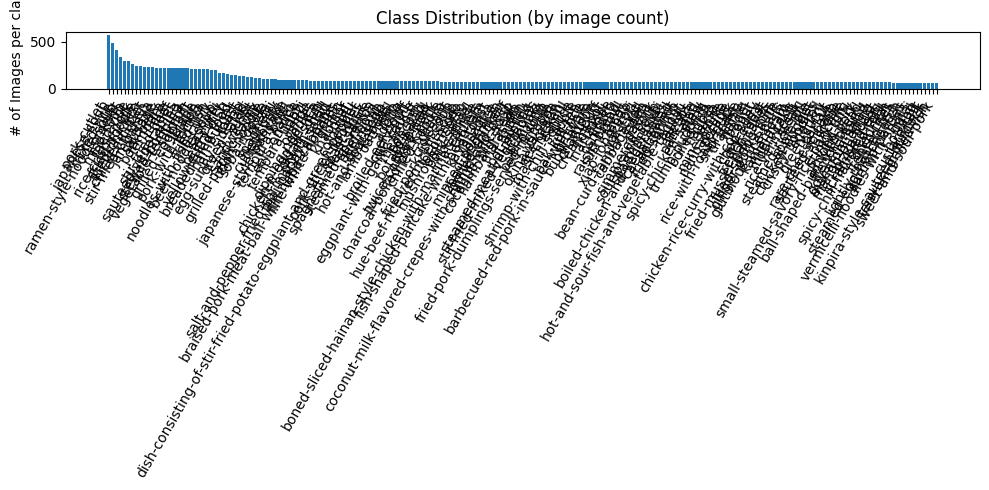

In [28]:
ds = Path("/content/augmented-V2-CareTech-Combined-Dataset-1")
labels_dir = ds / "train" / "labels"
num_classes = 210
image_count, label_files_by_class = count_images_per_class(ds,labels_dir,id_to_name, num_classes, True)

In [31]:
os.environ["AUDREY_API_KEY"] = userdata.get("AUDREY_API_KEY")
api_key = os.getenv("AUDREY_API_KEY")
rf_al = Roboflow(api_key=api_key)

In [ ]:
# ITERATION 4: training the final model after upscaling and augmenting minority classes
# Chosen model: yolov26 accurate, 70 epochs, img_size=640x640

WORKSPACE_SLUG = "audreys-workspace-po1fb"
workspace = rf_al.workspace(WORKSPACE_SLUG)
workspace.upload_dataset(
   "/content/augmented-V2-CareTech-Combined-Dataset-1", # dataset path
   "augmented-dataset-spyhe", # project id (slug)
   num_workers=10,
   project_license="MIT",
   project_type="object-detection",
   batch_name='augmented-dataset-spyhe',
   num_retries=0,
   is_prediction=False,
)
